# Biobío vuelve a estudiar
## Edad, reconversión y educación superior en una región que envejece · Base 2021

**Trabajo Práctico — Estadística Descriptiva**  
**Integrantes:** _(completar)_ · **Sección:** _(completar)_ · **Docente:** _(completar)_

### Pregunta guía
**¿La educación superior del Biobío funciona de la misma manera para un joven que recién comienza y para un adulto que vuelve a estudiar?**

La idea del trabajo es mirar la educación superior como dos posibles momentos de vida: **formación inicial** y **reingreso o reconversión educativa**. Las tres preguntas obligatorias se mantienen, pero se interpretan dentro de este problema regional.

**Notación:** $f_i$ frecuencia absoluta · $F_i$ absoluta acumulada · $h_i$ relativa (%) · $H_i$ relativa acumulada (%)

**Criterio de interpretación:** este es un análisis descriptivo. Hablaremos de patrones, diferencias y asociaciones observadas, pero no afirmaremos causalidad cuando la base no permita demostrarla.


## ¿Por qué esta pregunta importa en Biobío?

El contexto demográfico y laboral regional hace que estudiar después de los 30 o 40 años sea una pregunta relevante, no un detalle secundario.

- En **2021**, el **20,5%** de la población residente del Biobío tenía 60 años o más, por encima del 19,2% nacional, según registros administrativos publicados por INE/MDSF.
- El **Censo 2024** muestra un índice de envejecimiento regional de **84,1**, frente a 19,2 en 1992.
- En los últimos años, SENCE Biobío ha puesto énfasis explícito en **reconversión laboral, capacitación y empleabilidad**, incluyendo acciones vinculadas al fortalecimiento industrial regional.

Estos antecedentes externos **no explican causalmente** lo observado en la base 2021. Sirven para justificar por qué resulta interesante estudiar cómo cambian las trayectorias educativas con la edad.

**Fuentes de contexto:**
- INE, Informe de Cuidados 2024 (datos 2021): https://www.ine.gob.cl/docs/default-source/conferencia-tecnica/presentaci%C3%B3n-mdsf---rraa.pdf
- INE, Censo 2024 Biobío: https://censo2024.ine.gob.cl/wp-content/uploads/2025/04/08.-Infografia_Biobio.pdf
- SENCE Biobío, trabajo del futuro y reconversión: https://sence.gob.cl/personas/noticias/sence-biobio-dialoga-sobre-los-desafios-y-oportunidades-del-trabajo-del-futuro-en-la-region


## 1. Carga de datos, población y muestra

**Población:** todas las matrículas de educación superior de la Región del Biobío en 2021.
**Muestra:** los 106.555 registros de la base entregada.
**Unidad de observación:** cada fila es **una matrícula**, no un estudiante ni una carrera. Una misma
carrera se repite tantas veces como alumnos se matricularon en ella. Esta distinción será clave en el Ítem 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Busca automáticamente el Excel, aunque Colab le agregue (1), (2), etc.
archivos = list(Path('.').glob('11_MATRICULAS_ED_SUPERIOR_BIOBIO_2021*.xlsx'))

if not archivos:
    raise FileNotFoundError(
        'No se encontró el Excel. Súbelo al panel Archivos de Colab y vuelve a ejecutar.'
    )

archivo = archivos[0]
print('Archivo utilizado:', archivo.name)

df = pd.read_excel(archivo, sheet_name='BASE DE DATOS')
df.head()


Archivo utilizado: 11_MATRICULAS_ED_SUPERIOR_BIOBIO_2021(2).xlsx


,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,AÑOS DE ACREDITACION,NOMBRE CARRERA,REQUISITO INGRESO,VIA DE INGRESO,MODALIDAD,JORNADA,TIPO PLAN CARRERA,NIVEL DE ESTUDIO CARRERA,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,52,Femenino,24,20 a 24,2016,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE CONCEPCION,ACREDITADA,11/11/2016 AL 11/11/2023,7.0,NUTRICION Y DIETETICA,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Salud,10,0,10,120000,4243207,Biobio,Concepcion,Concepcion
1,58,Masculino,49,40 y mas,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,5.0,TECNICO EN AUTOMATIZACION Y CONTROL INDUSTRIAL,Educacion Media,Ingreso Directo (regular),Presencial,Vespertino,Plan Regular,Pregrado,Carreras Tecnicas,Tecnologia,5,1,5,190000,1840000,Biobio,Concepcion,Concepcion
2,73,Masculino,21,20 a 24,2021,Primer semestre,Universidades Privadas,UNIVERSIDAD DEL DESARROLLO,ACREDITADA,15/12/2016 AL 15/12/2021,5.0,DERECHO,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Derecho,10,2,12,494445,5351640,Biobio,Concepcion,Concepcion
3,80,Femenino,24,20 a 24,2020,Primer semestre,Centros de Formacion Tecnica,CFT LOTA-ARAUCO,ACREDITADA,21/07/2019 AL 21/07/2023,4.0,CONSTRUCCION,Educacion Media,Ingreso Directo (regular),Presencial,Vespertino,Plan Regular,Pregrado,Carreras Tecnicas,Tecnologia,5,1,5,30000,1450000,Biobio,Concepcion,Lota
4,88,Femenino,25,25 a 29,2018,Primer semestre,Universidades CRUCH,UNIVERSIDAD DEL BIO-BIO,ACREDITADA,28/08/2019 AL 28/08/2024,5.0,INGENIERIA COMERCIAL,Educacion Media,Ingreso Directo (regular),Presencial,Diurno,Plan Regular,Pregrado,Carreras Profesionales,Administracion y Comercio,10,0,10,105000,3255000,Biobio,Concepcion,Concepcion


### Clasificación de las variables utilizadas

| Variable | Clasificación |
|---|---|
| `GENERO` | Cualitativa nominal |
| `EDAD` | Cuantitativa discreta |
| `TIPO DE INSTITUCION` | Cualitativa nominal |
| `NIVEL CARRERA` | Cualitativa ordinal |
| `AREA CONOCIMIENTO` | Cualitativa nominal |
| `JORNADA` | Cualitativa nominal |
| `DURACION TOTAL CARRERA (SEMESTRES)` | Cuantitativa discreta |
| `VALOR ARANCEL (PESOS)` | **Cuantitativa continua** |

### Limpieza: dos decisiones

**1. Solo pregrado.** Los Magíster, Doctorados y Postítulos (5.462 registros) tienen una lógica de precios
distinta y distorsionarían la comparación de aranceles. Se excluyen.

**2. Los aranceles en $0 son datos faltantes.** De los 490 aranceles en $0, **450 son de Postítulos y
Magíster**. No existe educación superior arancelada en $0 a esa escala: es dato faltante registrado como
cero. Se eliminan.

In [2]:
#Decisión 1: solo carreras de pregrado
pregrado = ['Carreras Profesionales', 'Carreras Tecnicas']
d = df[df['NIVEL CARRERA'].isin(pregrado)]

#Decisión 2: se eliminan los aranceles registrados en $0
d = d[d['VALOR ARANCEL (PESOS)'] > 0].copy()

#Tamaño de la base de trabajo
n = d.shape[0]

#Atajos para las variables cuantitativas principales
arancel = d['VALOR ARANCEL (PESOS)']
edad = d['EDAD']
duracion = d['DURACION TOTAL CARRERA (SEMESTRES)']

tabla_limpieza = pd.DataFrame({
    'Registros': [df.shape[0], df.shape[0] - n, n]
}, index = ['Base original', 'Eliminados', 'Base de trabajo'])

tabla_limpieza

,Registros
Base original,106555
Eliminados,5488
Base de trabajo,101067


## 2. Contexto regional interno de la base

Además del contexto demográfico, observamos cómo se distribuye la educación superior entre las provincias de **Concepción, Biobío y Arauco**. Este análisis territorial queda como contexto secundario; el eje principal del trabajo será **cómo cambia la trayectoria educativa según la edad**.

Para precios se crea un segundo DataFrame con **ofertas académicas únicas**. Una oferta se identifica por la combinación de institución, carrera, comuna, modalidad, jornada, duración, matrícula y arancel.


Ofertas académicas únicas: 1273


,Matrículas,% Matrículas,Ofertas únicas,% Ofertas,Arancel mediano oferta ($)
PROVINCIA SEDE,,,,,
Concepcion,85657,84.75,953,74.86,2146000.0
Biobio,12695,12.56,259,20.35,1770000.0
Arauco,2715,2.69,61,4.79,1450000.0


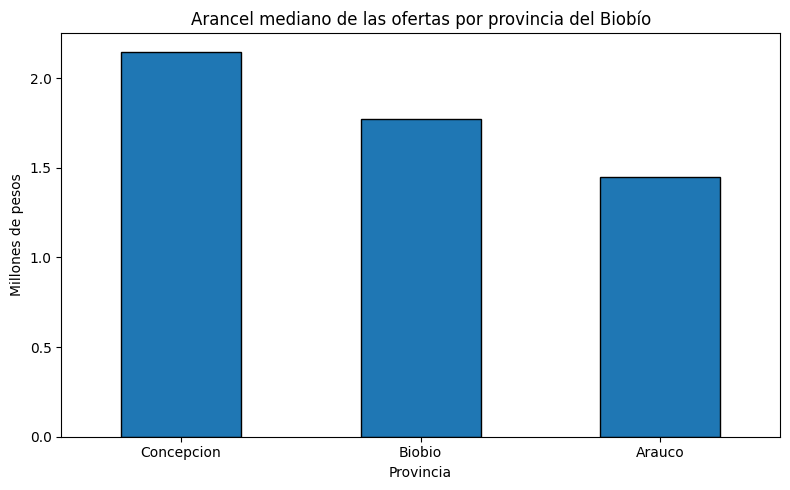

In [3]:
# DataFrame de ofertas académicas únicas para análisis de precios
clave_oferta = [
    'NOMBRE DE INSTITUCION',
    'NOMBRE CARRERA',
    'COMUNA SEDE',
    'MODALIDAD',
    'JORNADA',
    'DURACION TOTAL CARRERA (SEMESTRES)',
    'VALOR MATRICULA (PESOS)',
    'VALOR ARANCEL (PESOS)'
]

ofertas = d.drop_duplicates(subset=clave_oferta).copy()

mat_prov = d.groupby('PROVINCIA SEDE').size()
of_prov = ofertas.groupby('PROVINCIA SEDE').size()
med_prov = ofertas.groupby('PROVINCIA SEDE')['VALOR ARANCEL (PESOS)'].median()

tabla_regional = pd.DataFrame({
    'Matrículas': mat_prov,
    '% Matrículas': (mat_prov / len(d) * 100).round(2),
    'Ofertas únicas': of_prov,
    '% Ofertas': (of_prov / len(ofertas) * 100).round(2),
    'Arancel mediano oferta ($)': med_prov
}).sort_values('Matrículas', ascending=False)

print('Ofertas académicas únicas:', len(ofertas))
display(tabla_regional)

fig, ax = plt.subplots(figsize=(8,5))
(tabla_regional['Arancel mediano oferta ($)'] / 1_000_000).plot(
    kind='bar', ax=ax, edgecolor='black'
)
ax.set_title('Arancel mediano de las ofertas por provincia del Biobío')
ax.set_ylabel('Millones de pesos')
ax.set_xlabel('Provincia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretación territorial.** Concepción concentra **84,75% de las matrículas** y **74,86% de las ofertas académicas únicas**. Su arancel mediano de oferta es aproximadamente **$2,146 millones**, frente a **$1,770 millones** en Biobío y **$1,450 millones** en Arauco.

Este hallazgo ayuda a describir el escenario regional, pero **no es la tesis principal**. La pregunta central será qué ocurre cuando cambia la edad del estudiante y qué tipo de institución, jornada y nivel de precio aparecen asociados a esa trayectoria.


---
# ÍTEM 1 — Descripción general del conjunto de datos

## 1.1 Tabla de frecuencias: Área del conocimiento (variable cualitativa)

In [4]:
#Tabla de frecuencias del área del conocimiento
cuenta_area = d['AREA CONOCIMIENTO'].value_counts()

tabla_1 = pd.DataFrame({
    'Frecuencia Absoluta': cuenta_area,
    'Frecuencia Absoluta Acumulada': cuenta_area.cumsum(),
    'Frecuencia Relativa %': round((cuenta_area / n) * 100, 2),
    'Frecuencia Relativa Acumulada %': round((cuenta_area / n) * 100, 2).cumsum()
})

tabla_1

,Frecuencia Absoluta,Frecuencia Absoluta Acumulada,Frecuencia Relativa %,Frecuencia Relativa Acumulada %
AREA CONOCIMIENTO,,,,
Tecnologia,27866,27866,27.57,27.57
Salud,24597,52463,24.34,51.91
Administracion y Comercio,13500,65963,13.36,65.27
Educacion,11480,77443,11.36,76.63
Ciencias Sociales,10677,88120,10.56,87.19
Arte y Arquitectura,3611,91731,3.57,90.76
Derecho,3529,95260,3.49,94.25
Ciencias Basicas,2936,98196,2.91,97.16
Agropecuaria,2361,100557,2.34,99.50


**Interpretación.** La matrícula está muy concentrada: **Tecnología (27,57%) y Salud (24,34%) reúnen el
51,91% del total** ($H_2$), y al sumar Administración y Comercio se supera el 65%. En el otro extremo,
Humanidades alcanza solo un 0,50%.

Este resultado describe **qué áreas concentran estudiantes**, no por qué ocurre. Más adelante se comparará
esta estructura con el territorio regional para ver si la oferta y los precios también presentan concentración
entre las provincias de Concepción, Biobío y Arauco.


## 1.2 Tabla de frecuencias por intervalos: Arancel (variable cuantitativa continua)

Al ser continua, el arancel debe agruparse en intervalos con `pd.cut`. La **regla de Sturges** sugiere 18
intervalos, pero con esa cantidad la tabla se vuelve ilegible y varias clases quedan casi vacías. Siguiendo
el criterio de los laboratorios (8, 9 y 10 intervalos), **se usan 8**.

In [5]:
#Regla de Sturges
cantidad_intervalos = round(1 + np.log2(n), 0)
print(cantidad_intervalos)

18.0


In [6]:
#Tabla de frecuencias del arancel agrupado en 8 intervalos
d['Intervalo_Arancel'] = pd.cut(d['VALOR ARANCEL (PESOS)'], bins = 8, include_lowest=True, precision=0)
cuenta_arancel = d.groupby('Intervalo_Arancel').size()

tabla_2 = pd.DataFrame({
    'Frecuencia Absoluta': cuenta_arancel,
    'Frecuencia Absoluta Acumulada': cuenta_arancel.cumsum(),
    'Frecuencia Relativa %': round((cuenta_arancel / n) * 100, 2),
    'Frecuencia Relativa Acumulada %': round((cuenta_arancel / n) * 100, 2).cumsum()
})

tabla_2

/tmp/ipykernel_656/1929123334.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cuenta_arancel = d.groupby('Intervalo_Arancel').size()


,Frecuencia Absoluta,Frecuencia Absoluta Acumulada,Frecuencia Relativa %,Frecuencia Relativa Acumulada %
Intervalo_Arancel,,,,
"(641865.0, 1666709.0]",12036,12036,11.91,11.91
"(1666709.0, 2683418.0]",34015,46051,33.66,45.57
"(2683418.0, 3700126.0]",19227,65278,19.02,64.59
"(3700126.0, 4716835.0]",20582,85860,20.36,84.95
"(4716835.0, 5733544.0]",9530,95390,9.43,94.38
"(5733544.0, 6750252.0]",2244,97634,2.22,96.60
"(6750252.0, 7766961.0]",2370,100004,2.34,98.94
"(7766961.0, 8783670.0]",1063,101067,1.05,99.99


**Interpretación.**

- $f_2 = 34.015$ y $h_2 = 33{,}66\%$: el intervalo $(1.666.709 ; 2.683.418]$ es la **clase modal**.
  Aproximadamente una de cada tres matrículas está asociada a un arancel dentro de ese rango.
- $F_4 = 85.860$ y $H_4 = 84{,}95\%$: casi el 85% de las matrículas registra un arancel inferior a
  $4,72 millones.
- El último intervalo contiene 1.063 matrículas (1,05%), por lo que los valores extremadamente altos son
  poco frecuentes cuando se observa la base por matrícula.

La distribución no es uniforme: existen concentraciones en distintos rangos de precio y una cola hacia
valores altos. En el Ítem 2 se cambiará la **unidad de análisis** para estudiar precios por oferta académica
única y no por número de estudiantes.


## 1.3 Tabla de frecuencias de dos variables: Género × Tipo de institución

In [7]:
#Tabla de doble entrada, en porcentaje dentro de cada tipo de institución
cuenta_genero = d.groupby(['GENERO', 'TIPO DE INSTITUCION']).size()
tabla_3 = cuenta_genero.unstack()

tabla_3_1 = round((tabla_3 / d.groupby('TIPO DE INSTITUCION').size()) * 100, 2)
tabla_3_1

TIPO DE INSTITUCION,Centros de Formacion Tecnica,Institutos Profesionales,Universidades (* Carrera en Convenio),Universidades CRUCH,Universidades Privadas
GENERO,,,,,
Femenino,52.97,53.45,33.33,48.79,63.35
Masculino,47.03,46.55,66.67,51.21,36.65


**Interpretación.** Existe una leve mayoría femenina en la base y la composición por género cambia según
el tipo de institución. Las **Universidades Privadas** presentan la mayor participación femenina, mientras
que las instituciones CRUCH están más próximas al equilibrio.

Esta tabla muestra una **asociación descriptiva** entre género y tipo de institución. Por sí sola no permite
afirmar la causa de esas diferencias, porque también intervienen variables como área de estudio, carrera,
jornada y composición de la oferta.


## 1.4 Medidas de tendencia central, percentiles y dispersión

> **Sobre el comando `.quantile()`.** Un percentil $P_k$ es el valor que deja por debajo al $k\%$ de los
> datos ordenados. Es exactamente la misma idea de la **frecuencia relativa acumulada $H_i$** de la tabla
> 1.2: allí se leyó que $H_4 = 84{,}95\%$, es decir, que el 84,95% de las matrículas cuesta menos de
> $4.716.835. La diferencia es que la tabla solo entrega los valores en los bordes de los intervalos,
> mientras que `.quantile(0.25)` devuelve el valor exacto que deja bajo sí al 25% de los datos.
>
> Los cuartiles son percentiles particulares: $Q_1 = P_{25}$, $Q_2 = P_{50}$ (la mediana) y $Q_3 = P_{75}$.

In [8]:
#Medidas de tendencia central
tabla_4 = pd.DataFrame({
    'Media': [arancel.mean(), edad.mean(), duracion.mean()],
    'Mediana': [arancel.median(), edad.median(), duracion.median()],
    'Moda': [arancel.mode()[0], edad.mode()[0], duracion.mode()[0]]
}, index = ['Arancel ($)', 'Edad (años)', 'Duración (semestres)'])

round(tabla_4, 2)

,Media,Mediana,Moda
Arancel ($),3224894.96,3133750.0,3373000
Edad (años),24.40,23.0,19
Duración (semestres),8.35,10.0,10


In [9]:
#Percentiles del arancel y de la edad
posiciones = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

tabla_5 = pd.DataFrame({
    'Arancel ($)': arancel.quantile(posiciones),
    'Edad (años)': edad.quantile(posiciones)
})

tabla_5.index = ['P10', 'P25', 'P50', 'P75', 'P90', 'P95']
tabla_5

,Arancel ($),Edad (años)
P10,1537000.0,19.0
P25,1988000.0,21.0
P50,3133750.0,23.0
P75,4261900.0,26.0
P90,5010660.0,32.0
P95,5875170.0,38.0


In [10]:
#Medidas de dispersión. El CV permite comparar variables con unidades distintas
tabla_6 = pd.DataFrame({
    'Rango': [arancel.max() - arancel.min(),
              edad.max() - edad.min(),
              duracion.max() - duracion.min()],
    'Varianza': [arancel.var(), edad.var(), duracion.var()],
    'Desviación estándar': [arancel.std(), edad.std(), duracion.std()],
    'RIC': [arancel.quantile(0.75) - arancel.quantile(0.25),
            edad.quantile(0.75) - edad.quantile(0.25),
            duracion.quantile(0.75) - duracion.quantile(0.25)],
    'CV %': [(arancel.std() / arancel.mean()) * 100,
             (edad.std() / edad.mean()) * 100,
             (duracion.std() / duracion.mean()) * 100]
}, index = ['Arancel ($)', 'Edad (años)', 'Duración (semestres)'])

round(tabla_6, 2)

,Rango,Varianza,Desviación estándar,RIC,CV %
Arancel ($),8133670,2.307333e+12,1518990.74,2273900.0,47.10
Edad (años),59,3.884000e+01,6.23,5.0,25.54
Duración (semestres),12,7.180000e+00,2.68,5.0,32.08


**Interpretación.**

**Tendencia central.** En el arancel la media ($3.224.895) supera a la mediana ($3.133.750), lo que indica
una cola hacia valores altos. Por eso la mediana es útil para representar el centro sin quedar tan afectada
por observaciones extremas. En edad ocurre algo parecido: moda 19, mediana 23 y media 24,40.

**Percentiles.** El $P_{25}$ es $1.988.000 y el $P_{75}$ $4.261.900. Esto significa que el 50% central de
las matrículas se ubica entre ambos valores. El $P_{90}$ del arancel es $5.010.660 y el $P_{90}$ de edad es
32 años.

**Dispersión.** El arancel presenta el mayor coeficiente de variación de las tres variables analizadas.
Esto confirma una fuerte heterogeneidad en los valores asociados a las matrículas.


## 1.5 Otros resúmenes: el arancel según tipo de institución

In [11]:
#Resumen del arancel por tipo de institución
cuenta_institucion = d.groupby('TIPO DE INSTITUCION').size()
mediana_institucion = d.groupby('TIPO DE INSTITUCION')['VALOR ARANCEL (PESOS)'].median()

tabla_7 = pd.DataFrame({
    'Matrículas': cuenta_institucion,
    'Frecuencia Relativa %': round((cuenta_institucion / n) * 100, 2),
    'Arancel Mediano': mediana_institucion
})

tabla_7 = tabla_7.sort_values('Arancel Mediano')
tabla_7

,Matrículas,Frecuencia Relativa %,Arancel Mediano
TIPO DE INSTITUCION,,,
Centros de Formacion Tecnica,9455,9.36,1741000.0
Institutos Profesionales,26698,26.42,1870000.0
Universidades (* Carrera en Convenio),9,0.01,2229000.0
Universidades CRUCH,37997,37.60,3600000.0
Universidades Privadas,26908,26.62,4250000.0


**Interpretación.** Se observan diferencias claras en los aranceles medianos según tipo de institución:
CFT e IP presentan medianas menores que las universidades. Además, CRUCH y universidades privadas
concentran conjuntamente cerca del 64% de las matrículas analizadas.

La categoría *Universidades (* Carrera en Convenio)* tiene solo 9 matrículas, por lo que debe interpretarse
con cautela y no usarse para conclusiones generales.


## 1.6 Gráficos

Se usan los tres tipos del Laboratorio 3: **circular** y **barras separadas** para variables cualitativas,
y **barras unidas** (`width=1`) para la variable continua agrupada en intervalos.

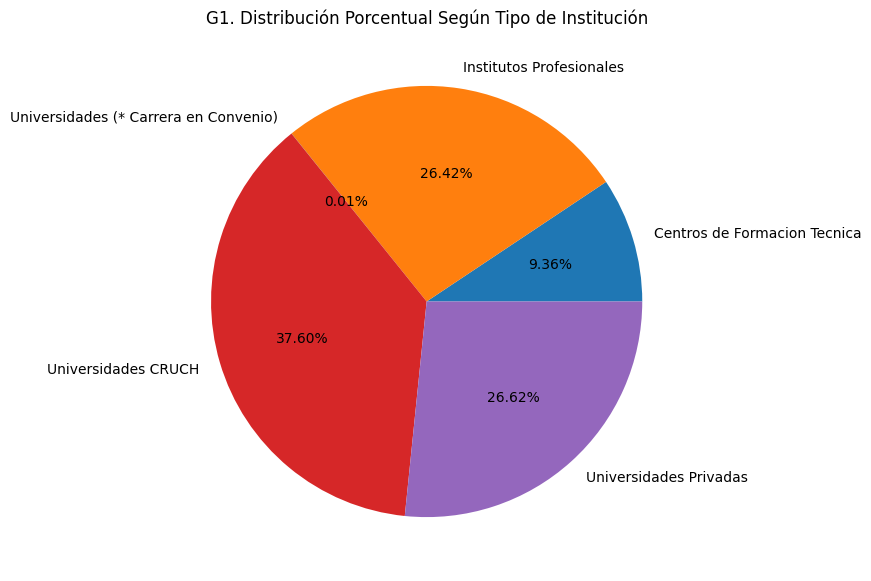

In [12]:
#G1: Gráfico circular - distribución por tipo de institución
h_institucion = tabla_7['Frecuencia Relativa %']
categorias_institucion = tabla_7.index

fig, ax = plt.subplots(figsize=(7, 7))
circular_institucion = ax.pie(h_institucion, labels=categorias_institucion, autopct='%.2f%%')
ax.set_title('G1. Distribución Porcentual Según Tipo de Institución')
plt.show()

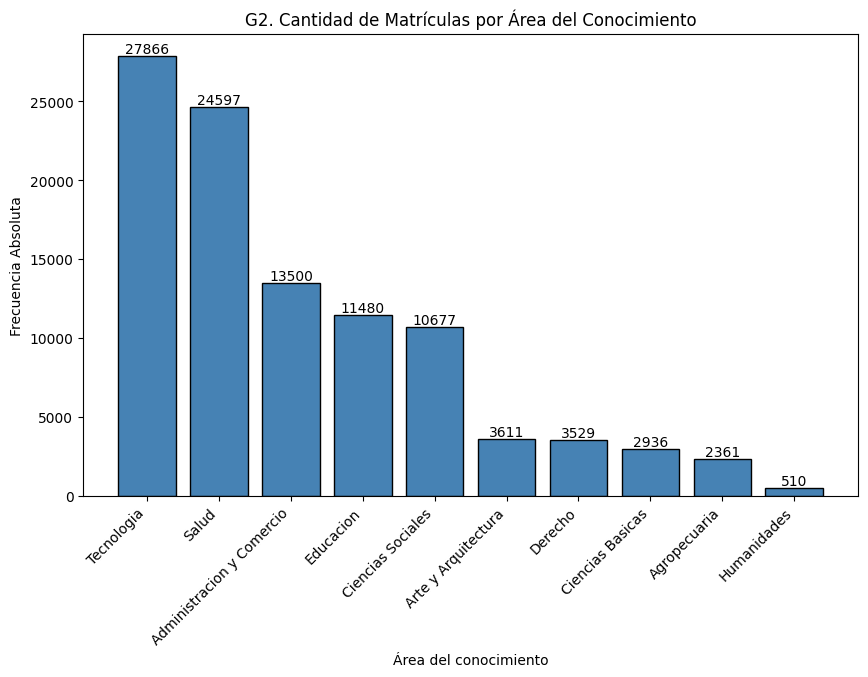

In [13]:
#G2: Gráfico de barras separadas - matrículas por área del conocimiento
categorias_area = tabla_1.index
f_area = tabla_1['Frecuencia Absoluta']

fig, ax = plt.subplots(figsize=(10, 6))
barras_area = ax.bar(categorias_area, f_area, color = "steelblue", edgecolor = "black")
ax.set_title('G2. Cantidad de Matrículas por Área del Conocimiento')
ax.set_xlabel('Área del conocimiento')
ax.set_ylabel('Frecuencia Absoluta')
ax.bar_label(barras_area)
plt.xticks(rotation=45, ha = "right")
plt.show()

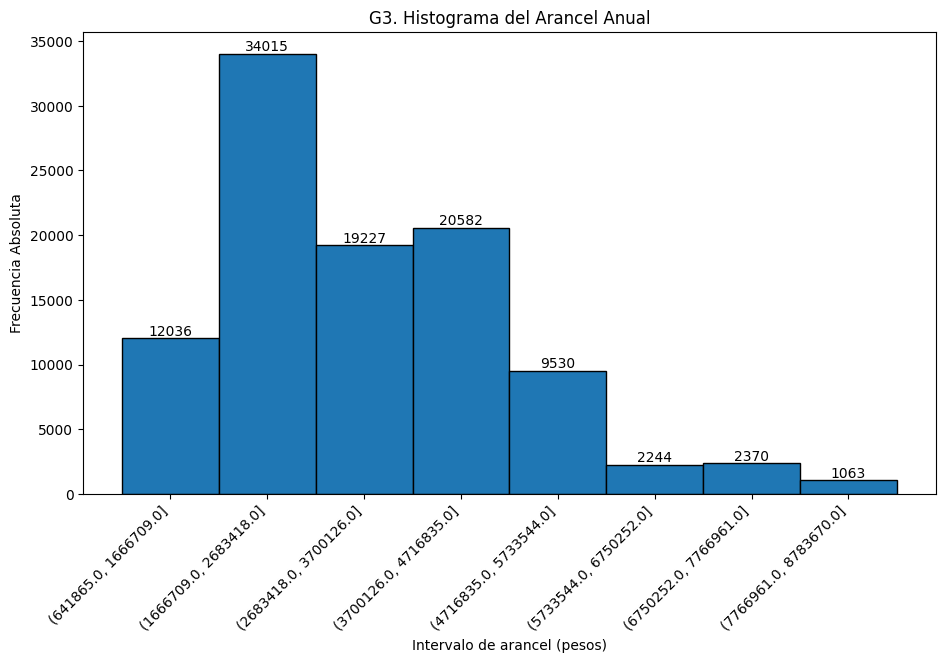

In [14]:
#G3: Gráfico de barras unidas (histograma) - distribución del arancel
categorias_arancel = tabla_2.index.astype(str)
f_arancel = tabla_2['Frecuencia Absoluta']

fig, ax = plt.subplots(figsize=(11, 6))
histograma_arancel = ax.bar(categorias_arancel, f_arancel, width=1, edgecolor = "black")
ax.set_title('G3. Histograma del Arancel Anual')
ax.set_xlabel('Intervalo de arancel (pesos)')
ax.set_ylabel('Frecuencia Absoluta')
ax.bar_label(histograma_arancel)
plt.xticks(rotation=45, ha="right")
plt.show()

**Interpretación de los gráficos.** **G1** muestra que CRUCH es el tipo de institución con mayor participación
en la matrícula regional. **G2** evidencia la concentración de estudiantes en Tecnología y Salud.
**G3** muestra que la distribución del arancel no es uniforme y posee una cola hacia valores altos.

Estos gráficos describen la base por matrícula. Para responder preguntas sobre **cuánto cuesta una carrera u
oferta**, el Ítem 2 utilizará ofertas académicas únicas para evitar que una oferta con muchos estudiantes
pese cientos de veces más que otra.


---
# ÍTEM 2 — Preguntas de investigación

## Pregunta 1 — ¿Hay áreas del conocimiento donde las carreras sean más caras? ¿Qué criterio diseñaron?

### Criterio principal
Como la pregunta habla del precio de **carreras/ofertas**, no usamos las 101.067 matrículas directamente.
Si una misma oferta tiene 500 estudiantes, su arancel no debe contarse 500 veces.

Por eso se usa el DataFrame **`ofertas`**, con una fila por oferta académica única, y se compara la
**mediana del arancel por área** con la mediana global.


Mediana global de las ofertas: $2,030,000


,Ofertas,Q1,Mediana,Q3,RIC,Diferencia vs mediana global
AREA CONOCIMIENTO,,,,,,
Derecho,18,2350000.0,3586000.0,4215000.0,1865000.0,1556000.0
Ciencias Basicas,31,2194500.0,3290000.0,4278045.0,2083545.0,1260000.0
Agropecuaria,18,1824250.0,2981500.0,4335000.0,2510750.0,951500.0
Tecnologia,491,1730000.0,2122000.0,2276000.0,546000.0,92000.0
Salud,131,1781000.0,2080000.0,4203000.0,2422000.0,50000.0
Humanidades,8,1717500.0,2006500.0,2579904.0,862404.0,-23500.0
Arte y Arquitectura,35,1786000.0,1940000.0,2826500.0,1040500.0,-90000.0
Administracion y Comercio,251,1537000.0,1855000.0,2122000.0,585000.0,-175000.0
Educacion,174,1399000.0,1722500.0,2654850.0,1255850.0,-307500.0


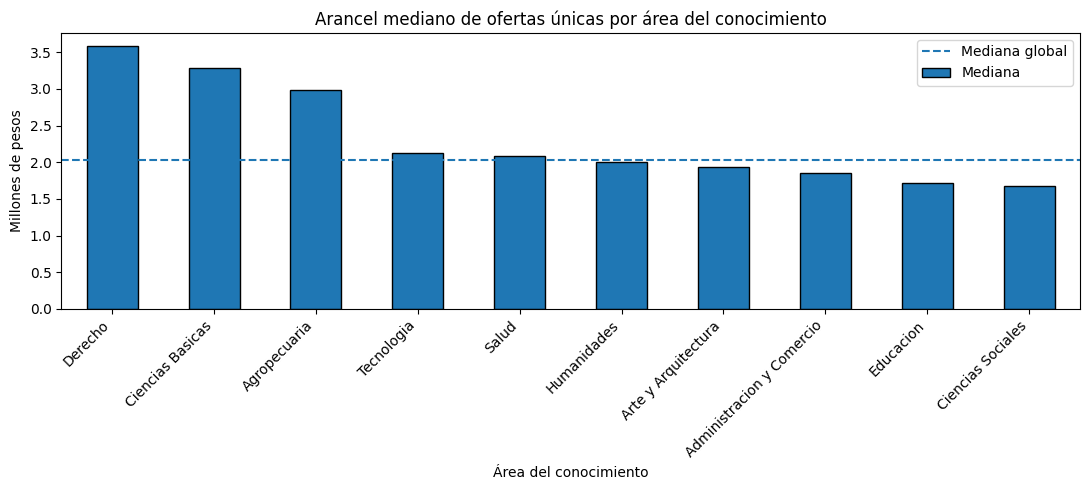

In [15]:
mediana_global = ofertas['VALOR ARANCEL (PESOS)'].median()

grupo_area = ofertas.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)']

tabla_p1 = pd.DataFrame({
    'Ofertas': grupo_area.size(),
    'Q1': grupo_area.quantile(0.25),
    'Mediana': grupo_area.median(),
    'Q3': grupo_area.quantile(0.75)
})

tabla_p1['RIC'] = tabla_p1['Q3'] - tabla_p1['Q1']
tabla_p1['Diferencia vs mediana global'] = tabla_p1['Mediana'] - mediana_global
tabla_p1 = tabla_p1.sort_values('Mediana', ascending=False)

print('Mediana global de las ofertas:', f'${mediana_global:,.0f}')
display(tabla_p1)

fig, ax = plt.subplots(figsize=(11,5))
(tabla_p1['Mediana'] / 1_000_000).plot(kind='bar', ax=ax, edgecolor='black')
ax.axhline(mediana_global / 1_000_000, linestyle='--', label='Mediana global')
ax.set_title('Arancel mediano de ofertas únicas por área del conocimiento')
ax.set_ylabel('Millones de pesos')
ax.set_xlabel('Área del conocimiento')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Respuesta

**Sí, existen diferencias importantes entre áreas.**

La mediana global de las **1.273 ofertas académicas únicas** es **$2.030.000**. Las tres áreas con mayor
mediana son:

1. **Derecho:** $3.586.000  
2. **Ciencias Básicas:** $3.290.000  
3. **Agropecuaria:** $2.981.500  

En el extremo inferior se encuentran Ciencias Sociales, Educación y Administración y Comercio.

**Conexión regional:** la diferencia por área convive con una diferencia territorial. Concepción concentra
la mayor cantidad de ofertas y también tiene un arancel mediano superior a Biobío y Arauco. Por eso,
“qué estudiar” y “dónde estudiar dentro del Biobío” son dos dimensiones del precio de elegir.


## Pregunta 2 — ¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?

La palabra “influencia” se interpreta de forma descriptiva. Con esta base podemos estudiar **asociación**,
pero no afirmar que la edad cause la elección de un tipo de institución.

La herramienta principal será una tabla de contingencia con **porcentajes dentro de cada rango de edad**.


TIPO DE INSTITUCION,Centros de Formacion Tecnica,Institutos Profesionales,Universidades (* Carrera en Convenio),Universidades CRUCH,Universidades Privadas
RANGO EDAD,,,,,
15 a 19,9.98,19.30,0.00,46.24,24.47
20 a 24,7.78,22.19,0.00,41.92,28.11
25 a 29,8.87,29.24,0.00,32.71,29.18
30 a 34,14.04,44.32,0.03,18.42,23.19
35 a 39,14.35,52.82,0.03,13.94,18.86
40 y mas,17.71,52.85,0.16,10.90,18.39


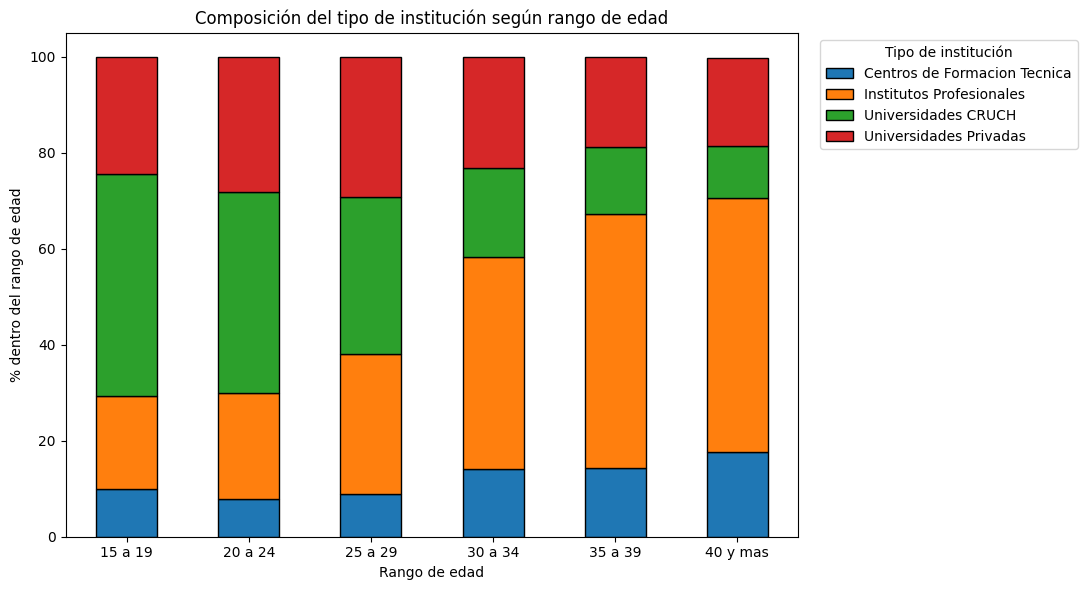

,Matrículas,Edad mediana
JORNADA,,
Diurno,80109,22.0
Vespertino,18092,28.0
A Distancia,1065,33.0
Otro,766,34.0
Semipresencial,1035,36.0


In [16]:
orden_edades = ['15 a 19', '20 a 24', '25 a 29', '30 a 34', '35 a 39', '40 y mas']

tabla_p2 = pd.crosstab(
    d['RANGO EDAD'].str.strip(),
    d['TIPO DE INSTITUCION'],
    normalize='index'
) * 100

tabla_p2 = tabla_p2.reindex(orden_edades).round(2)
display(tabla_p2)

graf_p2 = tabla_p2.drop(
    columns=['Universidades (* Carrera en Convenio)'],
    errors='ignore'
)

graf_p2.plot(
    kind='bar',
    stacked=True,
    figsize=(11,6),
    edgecolor='black'
)

plt.title('Composición del tipo de institución según rango de edad')
plt.ylabel('% dentro del rango de edad')
plt.xlabel('Rango de edad')
plt.legend(title='Tipo de institución', bbox_to_anchor=(1.02,1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Jornada como complemento descriptivo
tabla_jornada_edad = pd.DataFrame({
    'Matrículas': d.groupby('JORNADA').size(),
    'Edad mediana': d.groupby('JORNADA')['EDAD'].median()
}).sort_values('Edad mediana')

display(tabla_jornada_edad)


### Respuesta

**La edad está claramente asociada a una trayectoria institucional distinta.**

- En **15 a 19 años**, las universidades CRUCH representan aproximadamente **46,24%** y los IP **19,30%**.
- En **40 años o más**, los IP alcanzan aproximadamente **52,85%**, mientras CRUCH baja a **10,90%**.
- La participación relativa de CFT también aumenta en los grupos de mayor edad.

La jornada refuerza el patrón: la edad mediana es **22 años en diurno**, **28 en vespertino**, **33 a distancia** y **36 en semipresencial**. Esto sugiere que las modalidades más flexibles reciben estudiantes de mayor edad.

Además, en el resumen por tipo de institución, los aranceles medianos asociados a matrículas son aproximadamente **$1,741 millones en CFT** y **$1,870 millones en IP**, frente a **$3,600 millones en CRUCH** y **$4,250 millones en universidades privadas**. Este dato se usa como contexto descriptivo, no para afirmar que el precio cause la elección.

**Lectura del tema:** la educación superior regional parece cumplir funciones diferentes según la etapa de vida: las universidades tienen mayor peso entre los más jóvenes, mientras IP, CFT y jornadas flexibles ganan protagonismo entre estudiantes de mayor edad.


## Pregunta 3 — ¿Hay carreras cuyo arancel sea sustantivamente más caro que la mayoría?

Se usa un criterio reproducible basado en el **rango intercuartílico (RIC)**, aplicado sobre las
**ofertas académicas únicas**:

$$RIC = Q_3 - Q_1$$

$$Límite\ superior = Q_3 + 1{,}5\times RIC$$

Toda oferta con arancel superior al límite se clasifica como **sustantivamente alta**.


In [17]:
arancel_oferta = ofertas['VALOR ARANCEL (PESOS)']

Q1 = arancel_oferta.quantile(0.25)
Q3 = arancel_oferta.quantile(0.75)
RIC = Q3 - Q1
limite = Q3 + 1.5 * RIC

altas = ofertas[ofertas['VALOR ARANCEL (PESOS)'] > limite].copy()

tabla_p3 = pd.DataFrame({
    'Valor': [
        Q1,
        Q3,
        RIC,
        limite,
        len(altas),
        len(altas) / len(ofertas) * 100
    ]
}, index=[
    'Q1',
    'Q3',
    'RIC',
    'Límite superior',
    'Ofertas sobre el límite',
    '% de ofertas'
])

display(tabla_p3)

print('Ofertas altas por provincia')
display(altas['PROVINCIA SEDE'].value_counts())

print('Ofertas altas por tipo de institución')
display(altas['TIPO DE INSTITUCION'].value_counts())

print('Ofertas altas por área')
display(altas['AREA CONOCIMIENTO'].value_counts())


,Valor
Q1,1.616000e+06
Q3,2.580000e+06
RIC,9.640000e+05
Límite superior,4.026000e+06
Ofertas sobre el límite,1.350000e+02
% de ofertas,1.060487e+01


Ofertas altas por provincia


PROVINCIA SEDE
Concepcion    129
Biobio          6
Name: count, dtype: int64

Ofertas altas por tipo de institución


TIPO DE INSTITUCION
Universidades CRUCH       73
Universidades Privadas    62
Name: count, dtype: int64

Ofertas altas por área


AREA CONOCIMIENTO
Salud                        39
Tecnologia                   39
Ciencias Basicas             13
Ciencias Sociales            13
Administracion y Comercio    10
Agropecuaria                  9
Derecho                       7
Arte y Arquitectura           5
Name: count, dtype: int64

,Ofertas,Arancel_Mediano
NOMBRE CARRERA,,
MEDICINA,3,7490000.0
ODONTOLOGIA,5,7290000.0
INGENIERIA CIVIL QUIMICA,3,4804479.0
TECNOLOGIA MEDICA,4,4771050.0
INGENIERIA CIVIL INFORMATICA,3,4745935.0
MEDICINA VETERINARIA,6,4320000.0
KINESIOLOGIA,9,4224000.0
ARQUITECTURA,6,4214450.0
INGENIERIA CIVIL ELECTRICA,4,4202239.5


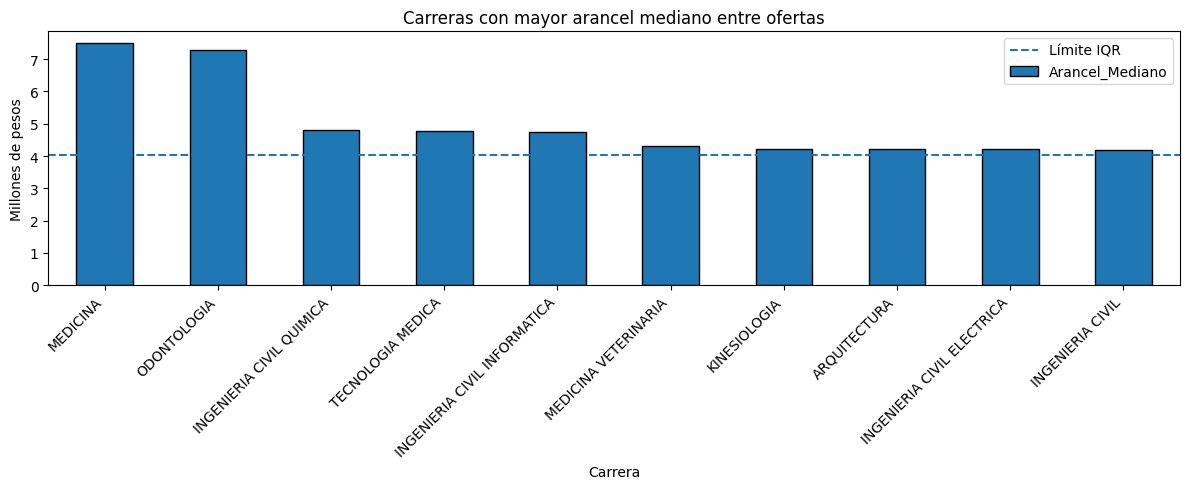

In [18]:
# Ranking de carreras por mediana de oferta.
# Se exige al menos 3 ofertas para evitar rankings dominados por un único caso.
ranking_carreras = ofertas.groupby('NOMBRE CARRERA')['VALOR ARANCEL (PESOS)'].agg(
    Ofertas='size',
    Arancel_Mediano='median'
)

ranking_carreras = ranking_carreras[
    ranking_carreras['Ofertas'] >= 3
].sort_values('Arancel_Mediano', ascending=False).head(10)

display(ranking_carreras)

fig, ax = plt.subplots(figsize=(12,5))
(ranking_carreras['Arancel_Mediano'] / 1_000_000).plot(
    kind='bar', ax=ax, edgecolor='black'
)
ax.axhline(limite / 1_000_000, linestyle='--', label='Límite IQR')
ax.set_title('Carreras con mayor arancel mediano entre ofertas')
ax.set_ylabel('Millones de pesos')
ax.set_xlabel('Carrera')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Respuesta

**Sí.** Con ofertas únicas:

- $Q_1$ = **$1.616.000**
- $Q_3$ = **$2.580.000**
- $RIC$ = **$964.000**
- Límite superior = **$4.026.000**

Superan este límite **135 de 1.273 ofertas**, aproximadamente **10,6%**.

### El hallazgo regional más fuerte
De esas 135 ofertas de arancel sustantivamente alto:

- **129 están en la provincia de Concepción**
- **6 están en la provincia de Biobío**
- **0 están en Arauco**

Además, todas pertenecen a **universidades CRUCH o universidades privadas**.

Esto conecta directamente la pregunta de precios con el territorio: los aranceles altos se concentran
fuertemente en Concepción. La base permite describir esa concentración, pero no demostrar que la ubicación
sea la causa del precio.


---
# Conclusiones generales — Biobío vuelve a estudiar

## Hallazgo principal
**La educación superior del Biobío cambia de forma con la edad.** Entre los más jóvenes predominan relativamente las universidades, mientras que en los grupos de mayor edad aumentan con fuerza IP y CFT y aparecen jornadas más flexibles.

Esto es especialmente relevante en una región que envejece y que hoy discute reconversión laboral y capacitación. Los datos de 2021 no permiten afirmar que una persona estudie por haber perdido un empleo o por necesidad de reconversión, pero sí muestran que **la educación superior no funciona únicamente como la continuación inmediata del colegio**. También recibe a personas de edades mayores mediante rutas institucionales y horarias distintas.

### Cómo se conectan las preguntas obligatorias
**1. Áreas y aranceles.** No todos los campos de formación cuestan lo mismo; Derecho, Ciencias Básicas y Agropecuaria presentan las mayores medianas entre ofertas únicas.

**2. Edad e institución.** Es el corazón del tema: a mayor edad cambia fuertemente la composición institucional y aumentan IP/CFT.

**3. Aranceles altos.** El criterio $Q_3 + 1{,}5\times RIC$ identifica **135 de 1.273 ofertas** sobre $4.026.000. Las 135 pertenecen a universidades: **73 CRUCH y 62 privadas**. Esto contrasta con los tipos de institución que ganan peso entre estudiantes mayores.

## Conclusión en una frase
**En un Biobío que envejece, estudiar deja de ser solo el primer paso de los jóvenes: los adultos aparecen con mucha más fuerza en IP, CFT y modalidades flexibles, mostrando una segunda puerta de entrada a la educación superior.**

## Limitaciones
- La base corresponde a 2021 y no sigue a una misma persona en el tiempo.
- No contiene motivo de matrícula, situación laboral previa ni ingreso del hogar, por lo que no podemos demostrar reconversión laboral individual.
- Los aranceles son valores de referencia y no necesariamente el monto efectivamente pagado.
- Las relaciones encontradas son descriptivas, no causales.
